In [33]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed


In [34]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [35]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))*np.exp( -(arr_x-min_l)**2/(2*xiV**2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

In [36]:
def dos_fun(E_imgxx, E_dis, Vdis, Vimg, t, alpha, omB, Zeeman ):
    def dos_onsite(site):
            xi, yi = site.pos
            om0 = 4 * t * sigma_0  # Original onsite energy
            omRan = E_dis * Vdis[int(yi)][int(xi)] * sigma_0  # Disorder
            omImg = E_imgxx * Vimg[int(yi)] * sigma_0  # Image charge

            H_Zeeman = Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

            return om0 + omRan + omImg + H_Zeeman  # Return as a 2x2 matrix
    def dos_hopping(site_i, site_j):
        xi, yi = site_i.pos
        xj, yj = site_j.pos
        return - t*np.exp(-1j * 2*np.pi * alpha * (xi - xj) * (yi + yj)/2.)* sigma_0
    sys_nolead = kwant.Builder()
    sys_nolead[(lat(x, y) for x in range(L) for y in range(W))] = dos_onsite
    sys_nolead[lat.neighbors()] = dos_hopping
    sys_nolead = sys_nolead.finalized()

    #dos = kwant.kpm.SpectralDensity(sys_nolead, num_vectors=80, energy_resolution=omB/80 )
    dos = kwant.kpm.SpectralDensity(sys_nolead, energy_resolution = E_dis/2. )
    
    return dos

@njit
def filling_fun_a(arr_mu, dos_energies, dos_densities, T, W, L, alpha):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        number_e[ne]= np.sum( np.divide( dos_densities ,  (np.exp( ( dos_energies - E)/T )+1)  ) )/(1.*N_dos)
    
    return number_e/((W-1)*(L-1)*alpha)

@njit
def filling_fun(arr_mu, dos_energies, dos_densities, T, W, L, alpha):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        for ndos in range(1,len(dos_densities)):
            dE = (dos_energies[ndos]-dos_energies[ndos-1])
            number_e[ne] += dE * dos_densities[ndos-1] / (np.exp( ( dos_energies[ndos-1] - E)/T )+1) 
    
    return number_e/((W-1)*(L-1)*alpha)

@njit
def filling_fun_0T(arr_mu, dos_energies, dos_densities, W, L, alpha):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        indx_fermi = np.argmin(np.abs(E-dos_energies))
        dos_F = dos_densities[0:indx_fermi]
        for ndos in range(1,len(dos_F)):
            number_e[ne] += dos_densities[ndos-1]*(dos_energies[ndos]-dos_energies[ndos-1])
    
    return number_e/((W-1)*(L-1)*alpha)

@njit
def fermi_f(T, E, dE):
    if np.abs(E / T) < 100.0:
        if dE / T < 1.0:
            dF = - np.exp(E / T) / (np.exp(E / T) + 1.0) ** 2.0 / T * dE
        else:
            dF = 1.0
    else:
        dF = 0.0
    return dF

"""@njit
def finite_temp(T, G, energies):
    W = np.zeros( len(G) )
    num_points = len(G)
    
    for n in range(num_points):
        weighted_sum = 0.0
        norm_factor = 0.0
        for i in range(1,num_points):
            dE = np.abs(energies[i] - energies[i - 1])
            E = energies[i-1] - energies[n]
            dF = 0
            if np.abs(E / T) < 200.0:
                dF = - np.exp(E / T) / (np.exp(E / T) + 1.0) ** 2.0 / T * dE
            else:
                dF = 0.0
            norm_factor += dF
            weighted_sum += G[i-1] * dF
        W[n] = weighted_sum / norm_factor if norm_factor != 0 else 0.0
    
    return W"""
    
@njit
def finite_temp(T, G, energies):
    W = np.zeros( len(G) )
    num_points = len(G)
    
    for n in range(num_points):
        weighted_sum = 0.0
        norm_factor = 0.0
        for i in range(1,num_points):
            dE = np.abs(energies[i] - energies[i - 1])
            E = energies[i-1] - energies[n]
            dF = 0
            if np.abs(E / T) < 200.0:
                dF = np.exp(E / T) / (np.exp(E / T) + 1.0) ** 2.0 / T * dE
            else:
                dF = 0.0
            norm_factor += dF
            weighted_sum += G[i-1] * dF
        W[n] = weighted_sum
    
    return W

In [40]:
# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 # real lattice spacing in GaAs, in nm
#BandW0 = 40   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2


lat = kwant.lattice.square(a=1, norbs=2)
Ncore = 5       #number of cores used in the calculation
iter_dis = 1
t = 1   # hopping rate for kwant
W = 300  # spatial width of the system ( Nx )
L = 100  # spatial length of the system ( Ny )
# Define Pauli matrices
sigma_0 = np.array([[1, 0], [0, 1]])  # Identity (spin-independent)
sigma_x = np.array([[0, 1], [1, 0]])  # Pauli X
sigma_y = np.array([[0, -1j], [1j, 0]])  # Pauli Y
sigma_z = np.array([[1, 0], [0, -1]])  # Zeeman term

alpha0 = .03

lB0 = 1./np.sqrt(2*np.pi*alpha0)
omB0 = 4*np.pi*alpha0


xic = lB0 * .5      # Correlation length and definition of disorder-potential array
Vdis = corr_dis(int(L), int(W), 1, xic)
plate_distance = 8*lB0      #edge-plate distance
Vimg = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
V_img_min = np.amin(Vimg)
Vimg = Vimg - V_img_min - lB0/plate_distance**2 
#E_img = omB0*lB0 * ( (plate_distance/lB0)**2 )/2. * 1         # Image charge amplitude in Zeeman
E_img = omB0*lB0 * 2.5
E_dis = omB0 * .001                   # disorder amplitude in cyclotrons

arr_en = omB0 *np.linspace(3.0,3.5, 220 )
G0 = np.zeros(len(arr_en))
GIMG = np.zeros(len(arr_en))

def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t * sigma_0  # Original onsite energy
    omRan = params.E_dis * params.V[int(yi)][int(xi)] * sigma_0  # Disorder
    omImg = params.E_img * Vimg[int(yi)] * sigma_0  # Image charge

    H_Zeeman = params.Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

    return om0 + omRan + omImg + H_Zeeman  # Return as a 2x2 matrix

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    
    return -t * np.exp(phase) * sigma_0  # Spin-preserving hopping

def onsite_lead(site, params):
    return 4 * t * sigma_0 + (params.Zeeman / 2) * sigma_z  # Zeeman in leads

def hopping_lead(site_i, site_j, params):
    return -t * sigma_0  # Spin-independent hopping

sys = kwant.Builder()
sys[(lat(x, y) for x in range(L) for y in range(W))] = onsite
sys[lat.neighbors()] = hopping

sym_left_lead = kwant.TranslationalSymmetry((-1, 0))
left_lead = kwant.Builder(sym_left_lead)
left_lead[(lat(0, y) for y in range(W))] = onsite_lead
left_lead[lat.neighbors()] = hopping_lead
sys.attach_lead(left_lead)
sys.attach_lead(left_lead.reversed())

sys = sys.finalized()


In [41]:
BandW_eff = 140   #total bandwidth in meV
l0_eff = np.sqrt(568/BandW_eff*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
B0_eff = 4.14*10**3. / (l0_eff * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2



print(E_img*BandW_eff/8*l0_eff, omB0*BandW_eff/8)

0.21642815543506308 6.5973445725385655


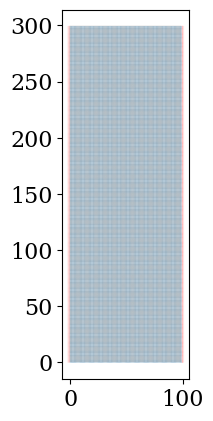

Text(0, 0.5, '$U_{\\rm img}/(\\hbar\\omega_B)$')

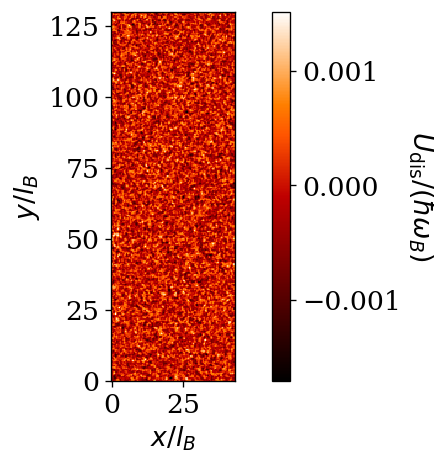

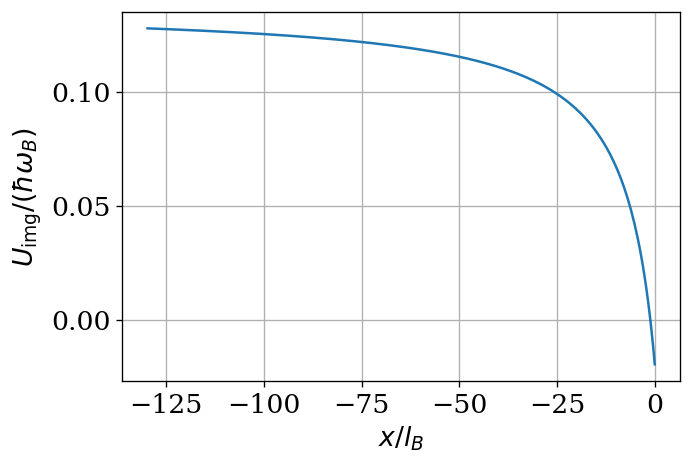

In [44]:
#plot some structural kwant stuff
kwant.plot(sys);

xvec = np.linspace(0, L-1, int(L) )
yvec = np.linspace(0, W-1, int(W) )
X, Y = np.meshgrid(xvec, yvec)

fig_W, ax_W = plt.subplots(dpi=120, figsize=(8, 4))
vmin = 0.
vmax = 1.000
Wmap_plot = ax_W.pcolormesh(X/lB0, Y/lB0, (Vdis.real*E_dis/omB0), cmap='gist_heat', alpha=1)  #, vmin=vmin, vmax=vmax)
cbar = fig_W.colorbar(Wmap_plot, ax=ax_W)
cbar.set_label(r'$U_{\rm dis}/(\hbar \omega_B)$', rotation=270, labelpad=20)

ax_W.set_xlabel(r'$x/l_B$')
ax_W.set_ylabel(r'$y/l_B$')
ax_W.set_aspect('equal')
#fig_W.savefig("disorder_potential.png", dpi=300, bbox_inches='tight')


fig_Img, ax_Img = plt.subplots(dpi=120, figsize=(6, 4))
ax_Img.plot( -yvec/lB0, E_img/omB0*(Vimg) )
ax_Img.grid()

ax_Img.set_xlabel(r'$x/l_B$')
ax_Img.set_ylabel(r'$U_{\rm img}/(\hbar\omega_B)$')
#ax_Img.set_aspect('equal')



In [43]:
for nG in range(1):
    E_img = omB0*lB0 * 2.5 * (1+nG)/2.


    def G_conductance(ne, arr_en):
        alpha = alpha0
        lB = 1./np.sqrt(2*np.pi*alpha)
        omB = 4*np.pi*alpha

        Zeeman = omB/5

        params =SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=0, V=Vdis, Vimg=Vimg, Zeeman=Zeeman )
        params_img = SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=E_img, V=Vdis, Vimg=Vimg, Zeeman=Zeeman )

        smat = kwant.smatrix(sys, energy=arr_en[ne], args=[params])
        smat_img = kwant.smatrix(sys, energy=arr_en[ne], args=[params_img])
        G0_EF = smat.transmission(0, 1)
        GIMG_EF = smat_img.transmission(0, 1)

        return G0_EF, GIMG_EF

    # Define a function to compute conductance for a single iteration
    def compute_conductance(ne):
        return G_conductance( ne, arr_en  )

    # Use joblib to parallelize the loop
    results = Parallel(n_jobs=Ncore)(
        delayed(compute_conductance)(ne) for ne in range(len(arr_en))
    )

    G0 = []
    GIMG = []
    # Aggregate the results
    for sG0, sGIMG in results:
        G0.append( sG0 )
        GIMG.append( sGIMG )
    G0 = np.asarray(G0)
    GIMG = np.asarray(GIMG)

    # save platos in a file
    # Parameters
    params = {
        "t": t,
        "W": W,
        "L": L,
        "xic": xic,
        "plate_distance": plate_distance,
        "E_dis": E_dis,
        "E_img": E_img,
        "omB0": omB0,
        "iter_dis": iter_dis,
        "Ncore": Ncore
    }

    # Create a DataFrame
    data = pd.DataFrame({
        'arrE': arr_en,
        'G0': G0,
        'GIMG': GIMG
    })

    # Write parameters and data to a file
    filename = 'G_%d.dat' % (nG)
    with open(filename, 'w') as f:
        # Write parameters as comments
        for key, value in params.items():
            f.write(f"# {key} = {value}\n")
        # Write the data
        data.to_csv(f, sep=' ', index=False, header=True)

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_5073/756872765.py:15: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
/var/folders/y4/dpq6l